In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

data = load_iris(as_frame=True)

X = data.data[['petal length (cm)', 'petal width (cm)']].values
y = data.target

tree_cls = DecisionTreeClassifier(max_depth=2, random_state=52)
tree_cls.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,52
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [3]:
from sklearn.tree import export_graphviz

export_graphviz(tree_cls, out_file='iris_tree.dot', feature_names=['petal length (cm)', 'petal width (cm)'], 
                class_names=data.target_names, rounded=True, filled=True)

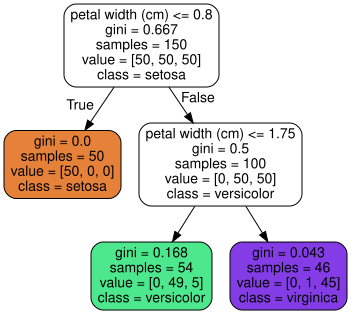

In [4]:
from graphviz import Source
Source.from_file('iris_tree.dot')

In [5]:
src = Source.from_file('iris_tree.dot')
src.render('iris_tree', format='png', cleanup=True)

'iris_tree.png'

In [6]:
print(tree_cls.predict_proba([[5,1.5]]))
print(tree_cls.predict([[5, 1.5]]))

[[0.         0.90740741 0.09259259]]
[1]


### Regularising 

In [7]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=52)

tree_cls1 = DecisionTreeClassifier(random_state=52)
tree_cls2 = DecisionTreeClassifier(random_state=52, min_samples_leaf=3)

tree_cls1.fit(X_moons, y_moons)
tree_cls2.fit(X_moons, y_moons)


X_test_moons, y_test_moons = make_moons(n_samples=1000, noise=0.2, random_state=47)

print(tree_cls1.score(X_test_moons, y_test_moons))
print(tree_cls2.score(X_test_moons, y_test_moons))

0.944
0.945


### Regression

In [8]:
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(seed=52)

X_quad = rng.random((200, 1))
y_quad = X_quad**2 + 0.025 * rng.standard_normal((200, 1))

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=52)
tree_reg.fit(X_quad, y_quad)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,52
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [9]:
export_graphviz(tree_reg, out_file='quad_tree_reg.dot', 
                 rounded=True, filled=True)

In [10]:
src = Source.from_file('quad_tree_reg.dot')
src.render('reg_tree', format='png', cleanup=True)

'reg_tree.png'

### Axis scaling

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

preprocessing = make_pipeline(StandardScaler(), PCA())
tree_cls = DecisionTreeClassifier(max_depth=2, random_state=52)

X_iris_pca = preprocessing.fit_transform(X)

tree_cls.fit(X_iris_pca, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,52
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
from sklearn.model_selection import cross_val_score

cross_val_score(tree_cls, X_iris_pca, y, cv=10, scoring='accuracy')

array([1.        , 1.        , 1.        , 1.        , 0.93333333,
       0.93333333, 0.93333333, 1.        , 1.        , 1.        ])

# Ex 7

In [505]:
from sklearn.model_selection import train_test_split
X, y = make_moons(n_samples=10000, noise=0.4, random_state=111)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=111, test_size=0.2)

In [ ]:
from sklearn.model_selection import GridSearchCV

params={ 'max_depth': [9,10,11,12], "max_leaf_nodes":[24,25,26,27,28], 'min_samples_leaf':[12,13,14,15,16], 'min_samples_split' : list(range(2, 30, 5))}
tree_cls = DecisionTreeClassifier(random_state=111)


grid_res = GridSearchCV(tree_cls, params, scoring='neg_root_mean_squared_error')
grid_res.fit(X_train, y_train)

,estimator,DecisionTreeC...dom_state=111)
,param_grid,"{'max_depth': [9, 10, ...], 'max_leaf_nodes': [24, 25, ...], 'min_samples_leaf': [12, 13, ...], 'min_samples_split': [2, 7, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [472]:
pd.DataFrame(grid_res.cv_results_).sort_values(by='mean_test_score', ascending=False).head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_leaf_nodes,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
341,0.008086,0.000118,0.000539,0.000083,11,25,13,27,"{'max_depth': 11, 'max_leaf_nodes': 25, 'min_s...",-0.378319,-0.362284,-0.388104,-0.378319,-0.372492,-0.375904,0.008458,1
342,0.008016,0.000153,0.000514,0.000055,11,25,14,2,"{'max_depth': 11, 'max_leaf_nodes': 25, 'min_s...",-0.378319,-0.362284,-0.388104,-0.378319,-0.372492,-0.375904,0.008458,1
343,0.007909,0.000163,0.000422,0.000007,11,25,14,7,"{'max_depth': 11, 'max_leaf_nodes': 25, 'min_s...",-0.378319,-0.362284,-0.388104,-0.378319,-0.372492,-0.375904,0.008458,1
350,0.007951,0.000133,0.000421,0.000010,11,25,15,12,"{'max_depth': 11, 'max_leaf_nodes': 25, 'min_s...",-0.378319,-0.362284,-0.388104,-0.378319,-0.372492,-0.375904,0.008458,1
351,0.007945,0.000147,0.000471,0.000090,11,25,15,17,"{'max_depth': 11, 'max_leaf_nodes': 25, 'min_s...",-0.378319,-0.362284,-0.388104,-0.378319,-0.372492,-0.375904,0.008458,1


In [473]:
best_tree = grid_res.best_estimator_
mae = -cross_val_score(best_tree, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

mean_y = np.mean(y_train)
percent_error = (mae.mean() / mean_y) * 100
print(f"Средняя ошибка ≈ {percent_error:.2f}%")


Средняя ошибка ≈ 28.19%


In [474]:
X_valid, y_valid = make_moons(n_samples=2000, noise=0.4, random_state=113)

In [475]:
from sklearn.metrics import accuracy_score

y_pred = best_tree.predict(X_valid)
accuracy_score(y_valid, y_pred)

0.851

In [476]:
y_pred = best_tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.869

## Ex 8

In [506]:
from sklearn.model_selection import ShuffleSplit

n_trees = 1000

splitter = ShuffleSplit(random_state=52, n_splits=n_trees, test_size=len(X_train)-1000)
sets = []

for train_indeces, test_indeces in splitter.split(X_train):
    X_train_set_n = X_train[train_indeces]
    y_train_set_n = y_train[train_indeces]

    sets.append([X_train_set_n, y_train_set_n])
    


In [507]:
#checking out X subset
(sets[0][0]).shape

(1000, 2)

In [508]:
#initializing and training trees
forest = []

for tree in range(n_trees):   
    forest.append(DecisionTreeClassifier(max_depth=11, max_leaf_nodes=25, min_samples_leaf=13,min_samples_split=27).fit(sets[tree][0], sets[tree][1]))


In [509]:
X_valid, y_valid = make_moons(n_samples=2000, noise=0.4, random_state=223)

#predictions
predictions = []
for tree in range(n_trees):
    predictions.append(forest[tree].predict(X_valid))

In [510]:
np.array(predictions).shape

(1000, 2000)

In [511]:
from scipy.stats import mode

res = np.array(mode(np.array(predictions), axis=0, keepdims=False))[0]
res.shape

(2000,)

In [512]:
accuracy_score(y_valid, res)

0.857

In [513]:
#test_set evaluating

#predictions
predictions = []
for tree in range(n_trees):
    predictions.append(forest[tree].predict(X_test))

res = np.array(mode(np.array(predictions), axis=0, keepdims=False))[0]

accuracy_score(y_test, res)

0.871

autor's way, I guess

In [500]:

n_trees = 1000

splitter = ShuffleSplit(random_state=52, n_splits=n_trees, test_size=len(X_train)-100)
sets = []

for train_indeces, test_indeces in splitter.split(X_train):
    X_train_set_n = X_train[train_indeces]
    y_train_set_n = y_train[train_indeces]

    sets.append([X_train_set_n, y_train_set_n])
    

In [501]:
forest = []

for tree in range(n_trees):   
    forest.append(DecisionTreeClassifier(max_depth=11, max_leaf_nodes=25, min_samples_split=27, random_state=111).fit(sets[tree][0], sets[tree][1]))

In [ ]:

#predictions
predictions = []
for tree in range(n_trees):
    min_samples_split=predictions.append(forest[tree].predict(X_test))

res = np.array(mode(np.array(predictions), axis=0, keepdims=False))[0]
min_samples_split=27
accuracy_score(y_test, res)

0.8575

all of these perform worse beacause my params suck, autor's ones are much better